In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize




In [23]:
headers=['polarity','id','date','query','name','tweet']

data=pd.read_csv("training.1600000.processed.noemoticon.csv",names=headers,encoding="latin-1")


In [4]:
data.tail()

,polarity,id,date,name,query,tweet
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...
1599999,4,2193602129,Tue Jun 16 08:40:50 PDT 2009,NO_QUERY,RyanTrevMorris,happy #charitytuesday @theNSPCC @SparksCharity...


In [50]:
data["tweet"]=data["tweet"].astype(str).fillna("")
data.head(10)


,polarity,id,date,name,query,tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


In [7]:

data.shape
print(f"number of rows : {data.shape[0]}")
print(f"number of columns : {data.shape[1]}")

number of rows : 1600000
number of columns : 6


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   polarity  1600000 non-null  int64 
 1   id        1600000 non-null  int64 
 2   date      1600000 non-null  object
 3   name      1600000 non-null  object
 4   query     1600000 non-null  object
 5   tweet     1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [26]:
missing_percentage=(data.isnull().sum()/len(data))*100

missing_data=pd.DataFrame({
    "missing_count": data.isnull().sum(),
    "percentage":missing_percentage})
print(missing_data)
print(" no missing data found")

          missing_count  percentage
polarity              0         0.0
id                    0         0.0
date                  0         0.0
query                 0         0.0
name                  0         0.0
tweet                 0         0.0
 no missing data found


In [26]:
duplicate_data_per_row=data.duplicated().sum()

if duplicate_data_per_row >0:
    data.drop_duplicates(keep="first".reset_index(True))
    print("duplicate data has been succesfully deleted")
else:
    print("no duplicate data found")
                        

no duplicate data found


In [8]:
nltk.download("stopwords",quiet=True)


True

In [6]:
stopwordlist=stopwords.words('english')
stopwordlist.remove('no')
stopwordlist.remove('not')
stopwordlist.remove('nor')

In [28]:
#vectorized count of character 
data['character_count']=data["tweet"].str.len()

#tokenization
wordseries=data["tweet"].str.lower().str.split()
#print(wordseries)

# vectorized count of token per tweet
data['token_count']=wordseries.str.len()




In [31]:
#average word length
total_chars=data["tweet"].str.replace(r'[^/w/s]','',regex=True).str.len()*10
data['avg_word_length']=(total_chars/data['token_count']).fillna(0)
print(data['avg_word_length'][0:3])

0    5.789474
1    2.857143
2    2.222222
Name: avg_word_length, dtype: float64


In [30]:
#stopwords
def stopword_count(list1):
    if not isinstance(list1,list):
        return 0
    return sum(1 for word in list1 if word in stopwordlist)

data['stopword_count']=wordseries.apply(stopword_count).fillna(0)
data['avg_stopword_ratio']=(data['stopword_count']/data['token_count'])



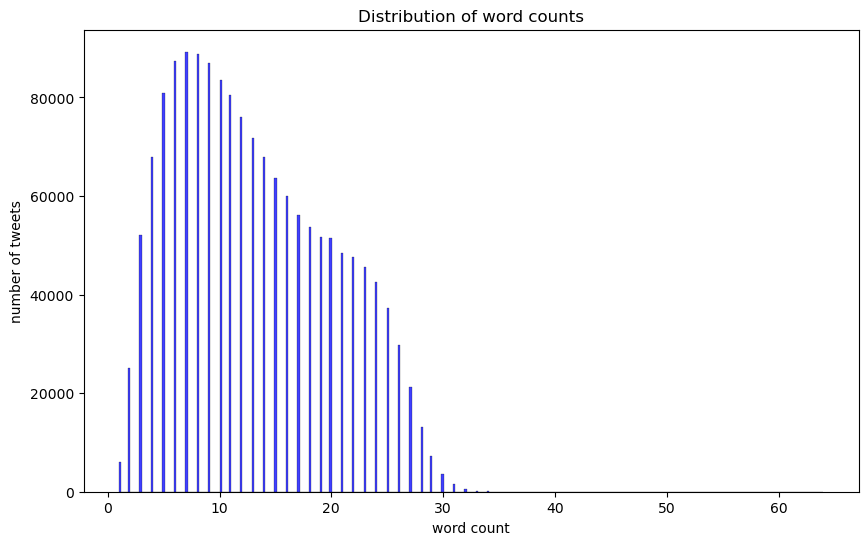

In [22]:
import seaborn as sns
plt.figure(figsize=(18,6))
sns.histplot(data['token_count'],color="blue")
plt.title("Distribution of word counts")
plt.xlabel('word count ')
plt.ylabel('number of tweets')
plt.show()


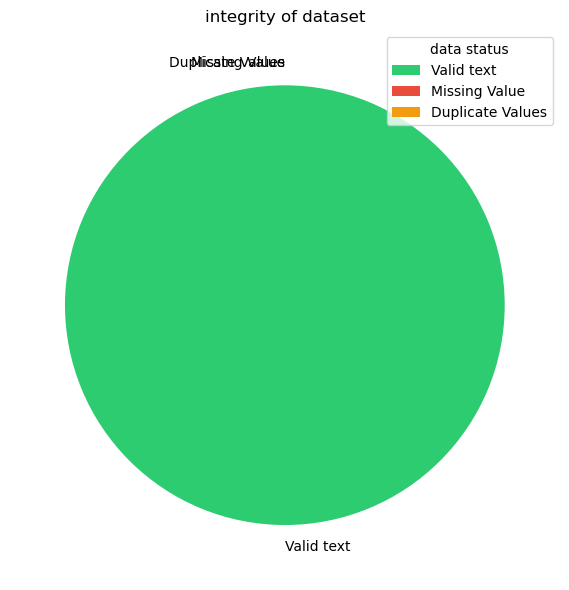

In [65]:
plt.figure(figsize=(18,6))
labels=['Valid text', 'Missing Value' , 'Duplicate Values']
data=[(1600000-duplicate_data_per_row+0),0,duplicate_data_per_row]
plt.pie(data,labels=labels,startangle=90,colors=['#2ecc71','#e74c3c','#f39c12'])
plt.title("integrity of dataset")
plt.legend(labels,title="data status",loc="upper right",)
plt.tight_layout()
plt.show()


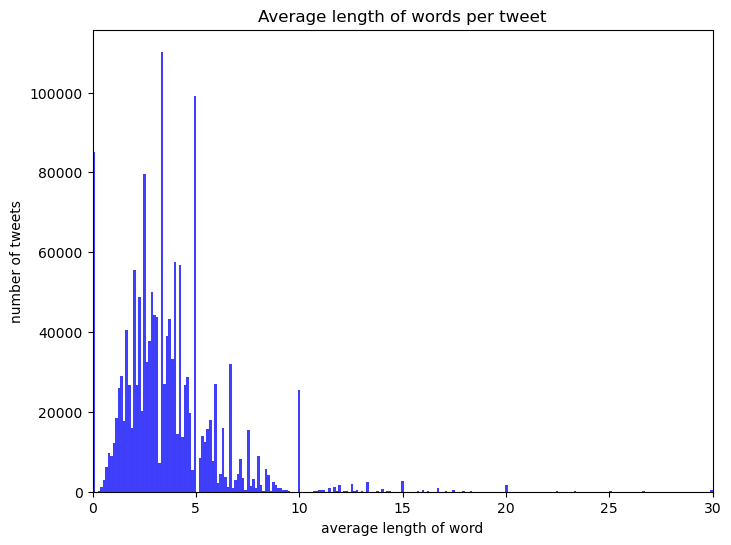

In [10]:
import seaborn as sns
avg=data['avg_word_length']
plt.figure(figsize=(8,6))
sns.histplot(avg,color="blue")
plt.xlim(0,30)
plt.title("Average length of words per tweet")
plt.xlabel('average length of word')
plt.ylabel('number of tweets')
plt.show()

In [72]:
data.groupby(by="polarity").count()

,id,date,name,query,tweet
polarity,,,,,
0,800000,800000,800000,800000,800000
4,800000,800000,800000,800000,800000


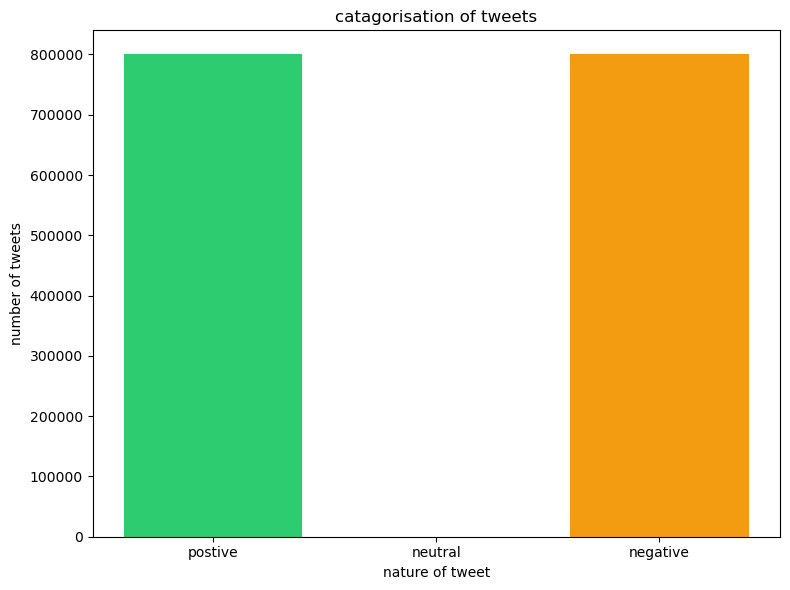

In [74]:
plt.figure(figsize=(8,6))
label=['postive','neutral','negative']
data=[800000,0,800000]
plt.bar(label,data,color=['#2ecc71','#e74c3c','#f39c12'])
plt.title("catagorisation of tweets")
plt.xlabel("nature of tweet")
plt.ylabel("number of tweets")
plt.tight_layout()
plt.show()

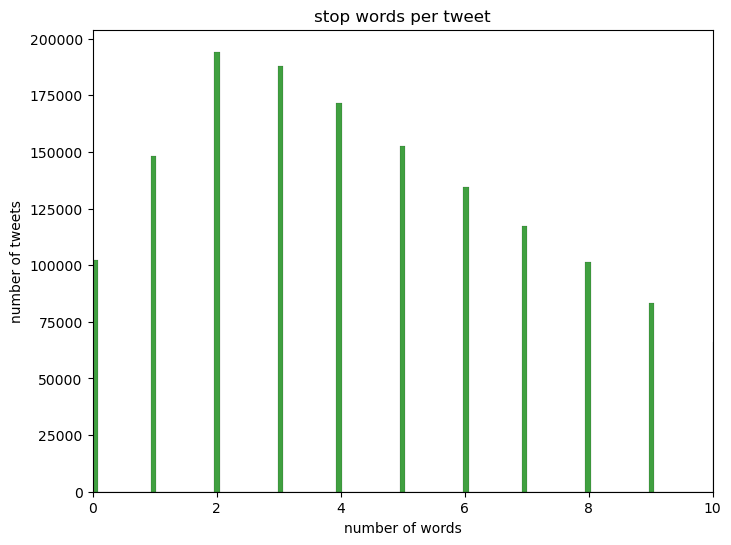

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(data['stopword_count'],color="green")
plt.xlim(0,10)
plt.title("stop words per tweet")
plt.xlabel('number of stop words')
plt.ylabel('number of tweets')
plt.show()

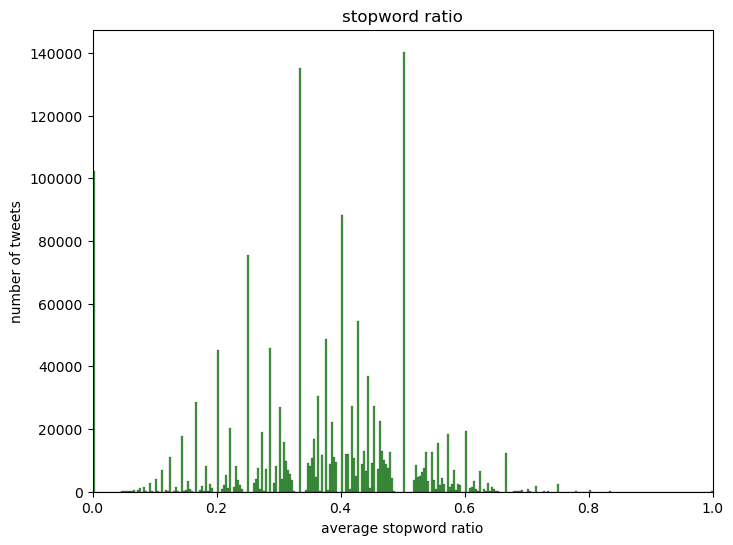

In [41]:
plt.figure(figsize=(8,6))
sns.histplot(data['avg_stopword_ratio'],color="green")
plt.xlim(0,1)
plt.title("stopword ratio")
plt.xlabel("average stopword ratio")
plt.ylabel('number of tweets')
plt.show()

In [32]:
data

,polarity,id,date,query,name,tweet,character_count,token_count,stopword_count,avg_stopword_ratio,avg_word_length
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115,19,5,0.263158,5.789474
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,21,8,0.380952,2.857143
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,18,7,0.388889,2.222222
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,10,4,0.400000,3.000000
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,21,11,0.523810,3.333333
...,...,...,...,...,...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...,56,11,4,0.363636,4.545455
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...,78,11,2,0.181818,4.545455
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...,57,11,6,0.545455,1.818182
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...,65,12,3,0.250000,0.000000
